# Probabilistic Graphical Model Visualization

A **probabilistic graphical model** (PGM) is a diagram that shows the
dependencies between all variables in a statistical model — which parameters
are free, which quantities are observed, and how they relate through
deterministic functions and probability distributions.

`spotgp` can generate PGMs automatically from a configured `GPSolver` or
`MultiBandGPSolver`. The diagram adapts to the model configuration: envelope
type, whether noise is a free parameter, single- vs. multi-band mode, etc.

**Diagram conventions:**

| Symbol | Meaning |
|---|---|
| Open circle | Latent (free) parameter |
| Shaded circle | Observed variable |
| Small dot | Fixed / known input |
| Ellipse | Deterministic function of parents |
| Rectangle (plate) | Repeated structure |
| Arrow | Dependency |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spotgp import (
    GPSolver,
    TrapezoidSymmetricEnvelope,
    TrapezoidAsymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    PGModelVis,
)
from spotgp.multiband import MultiBandData, MultiBandGPSolver

np.random.seed(42)

# Shared synthetic data for all examples
x = np.linspace(0, 30, 200)
y = 1.0 + 0.01 * np.sin(2 * np.pi * x / 5.0) + 0.001 * np.random.randn(len(x))
yerr = 0.001 * np.ones_like(x)

---
## 1. Default single-band GP

The simplest case: a symmetric trapezoid envelope with six free kernel
parameters ($P_{\rm eq}$, $\kappa$, $i$, $\ell_{\rm spot}$,
$\tau_{\rm spot}$, $\sigma_k$) and no free noise term.

The PGM shows how the rotation parameters feed into the visibility function
$V(\phi)$, the envelope parameters feed into $R_\Gamma(\tau)$, and both
combine with $\sigma_k$ to form the kernel $K(\tau)$ that generates the
observed flux $y_i$.

Banded Cholesky: bandwidth=199, N=200, sparsity=0.0%


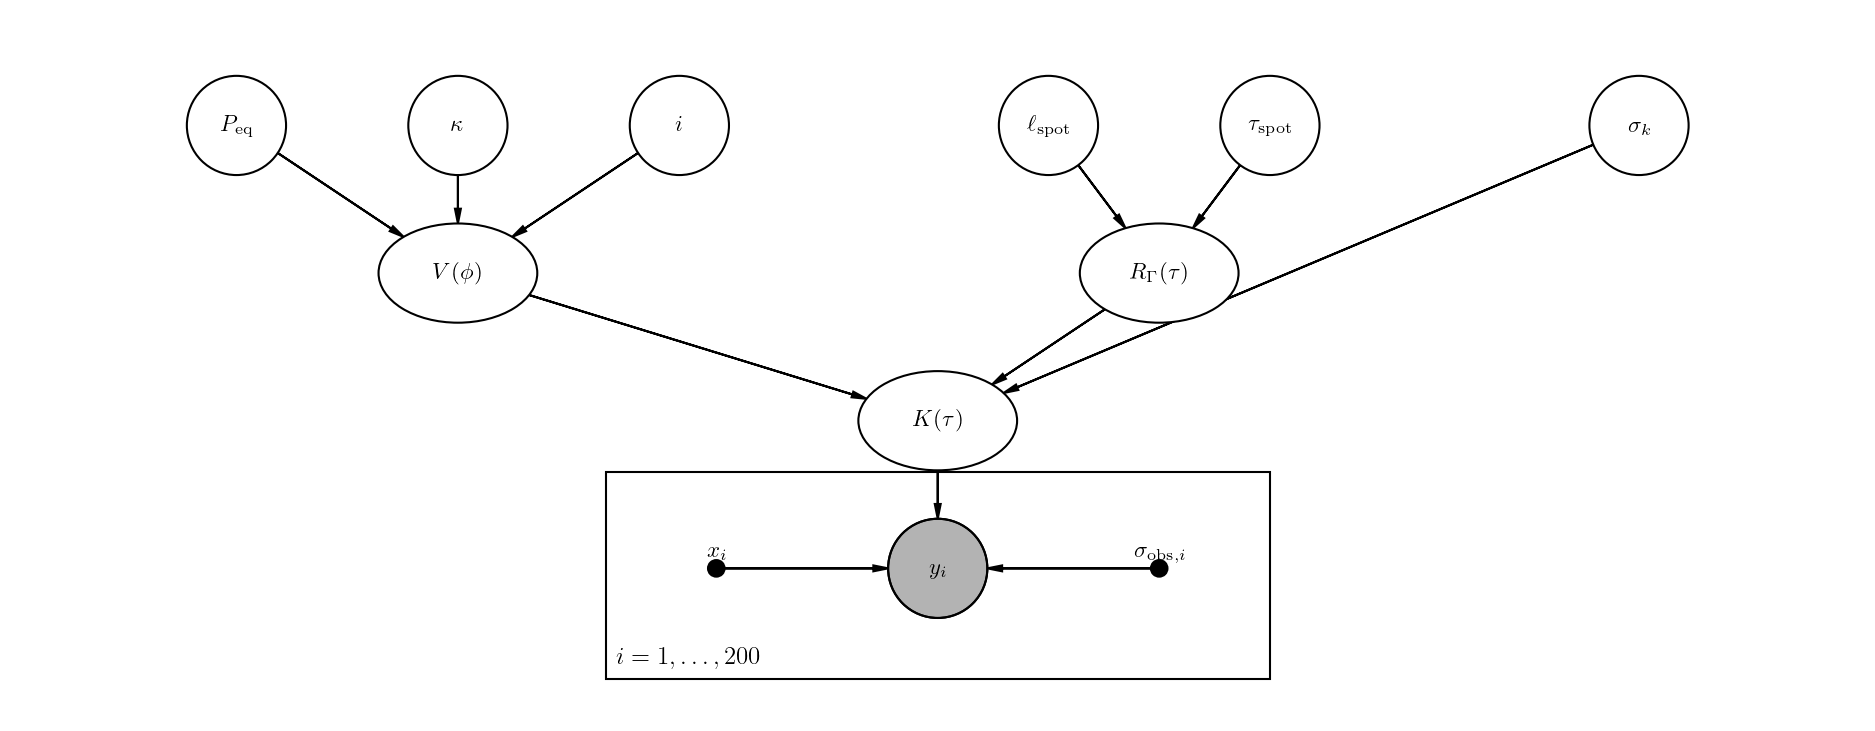

In [2]:
hparam = dict(peq=5.0, kappa=0.3, inc=1.2, lspot=5.0, tau_spot=2.0, sigma_k=0.01)

gp = GPSolver(x, y, yerr, hparam)
fig = gp.plot_pgm()
plt.show()

---
## 2. Adding white noise as a free parameter

Setting `fit_sigma_n=True` adds $\sigma_n$ as a seventh free parameter.
In the PGM it connects directly to $y_i$ (not through the kernel), reflecting
that white noise is added independently to each observation.

Banded Cholesky: bandwidth=199, N=200, sparsity=0.0%


Free parameters: ('peq', 'kappa', 'inc', 'lspot', 'tau_spot', 'sigma_k', 'sigma_n')


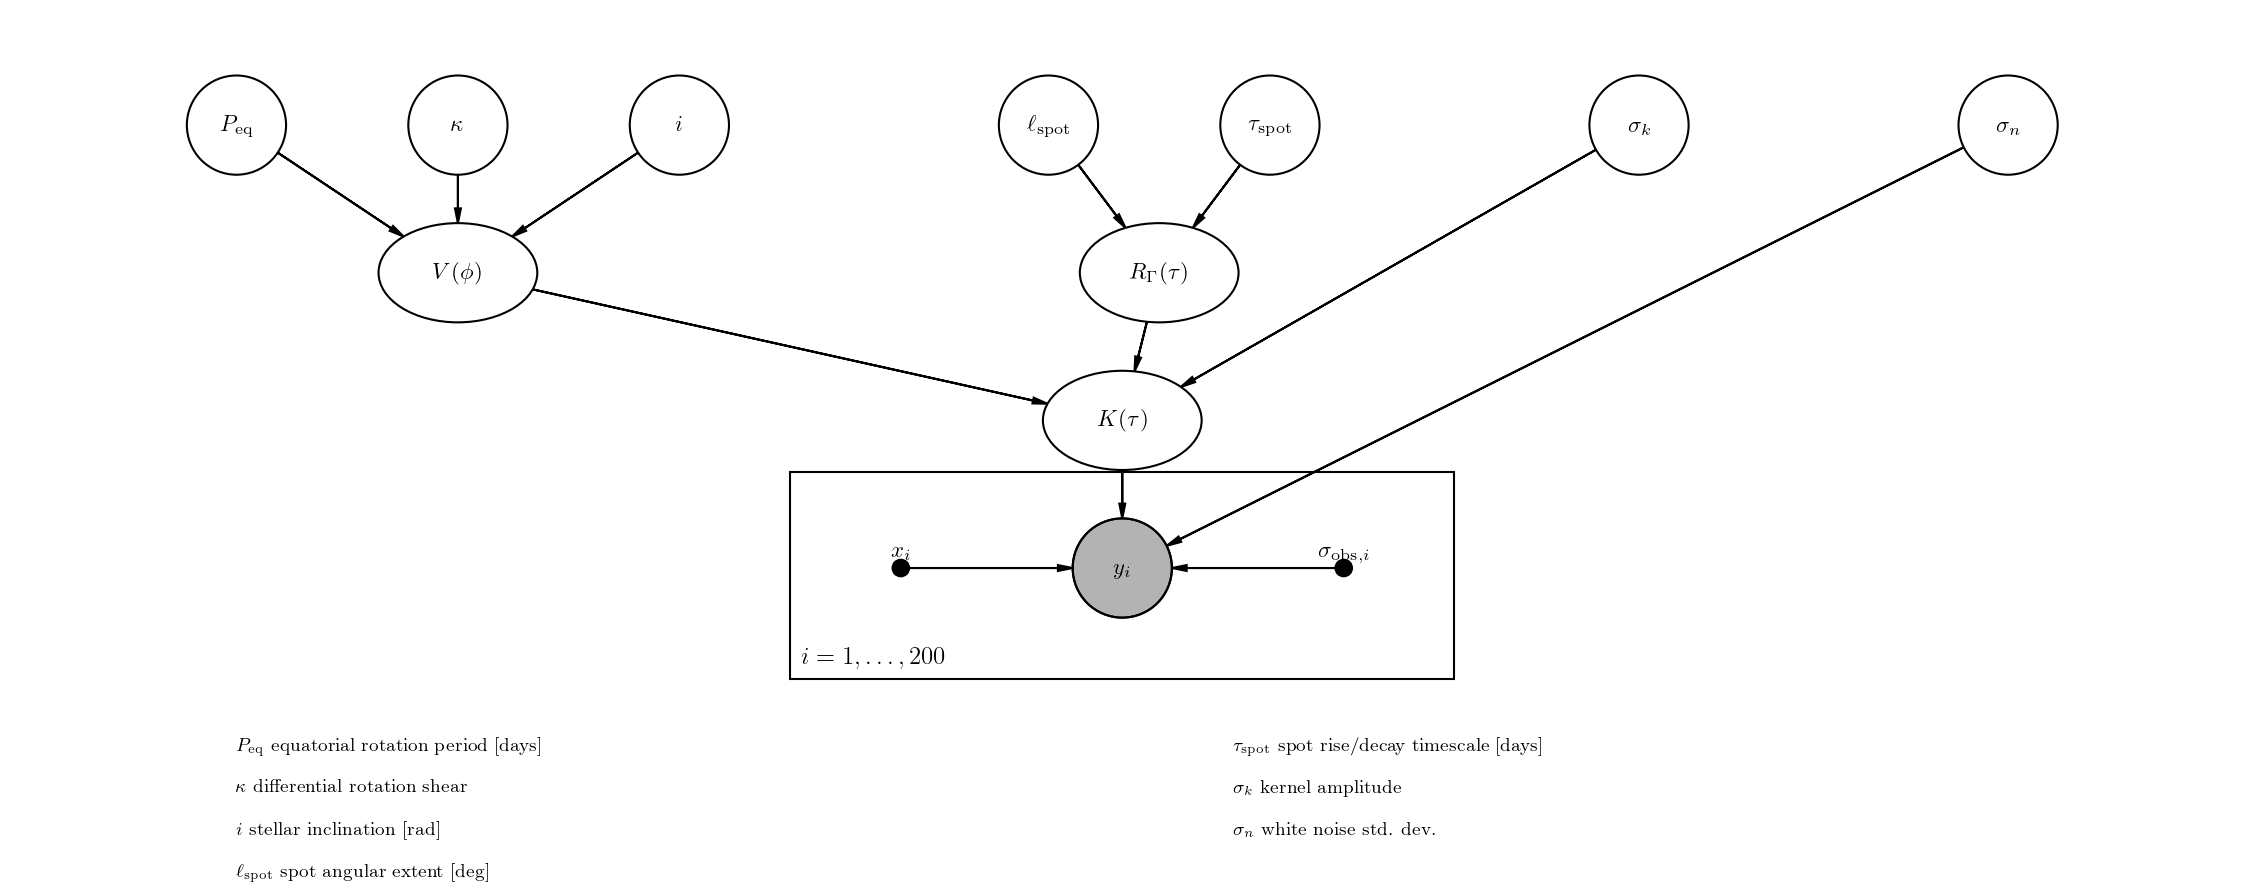

In [3]:
gp_noise = GPSolver(x, y, yerr, hparam, fit_sigma_n=True)

print("Free parameters:", gp_noise.param_keys)

fig = gp_noise.plot_pgm(show_legend=True)
plt.show()

---
## 3. Asymmetric envelope

Switching to a `TrapezoidAsymmetricEnvelope` replaces $\tau_{\rm spot}$ with
separate emergence and decay timescales ($\tau_{\rm em}$, $\tau_{\rm dec}$).
The PGM automatically shows three parameters feeding into $R_\Gamma(\tau)$
instead of two.

Banded Cholesky: bandwidth=199, N=200, sparsity=0.0%


Free parameters: ('peq', 'kappa', 'inc', 'lspot', 'tau_em', 'tau_dec', 'sigma_k', 'sigma_n')


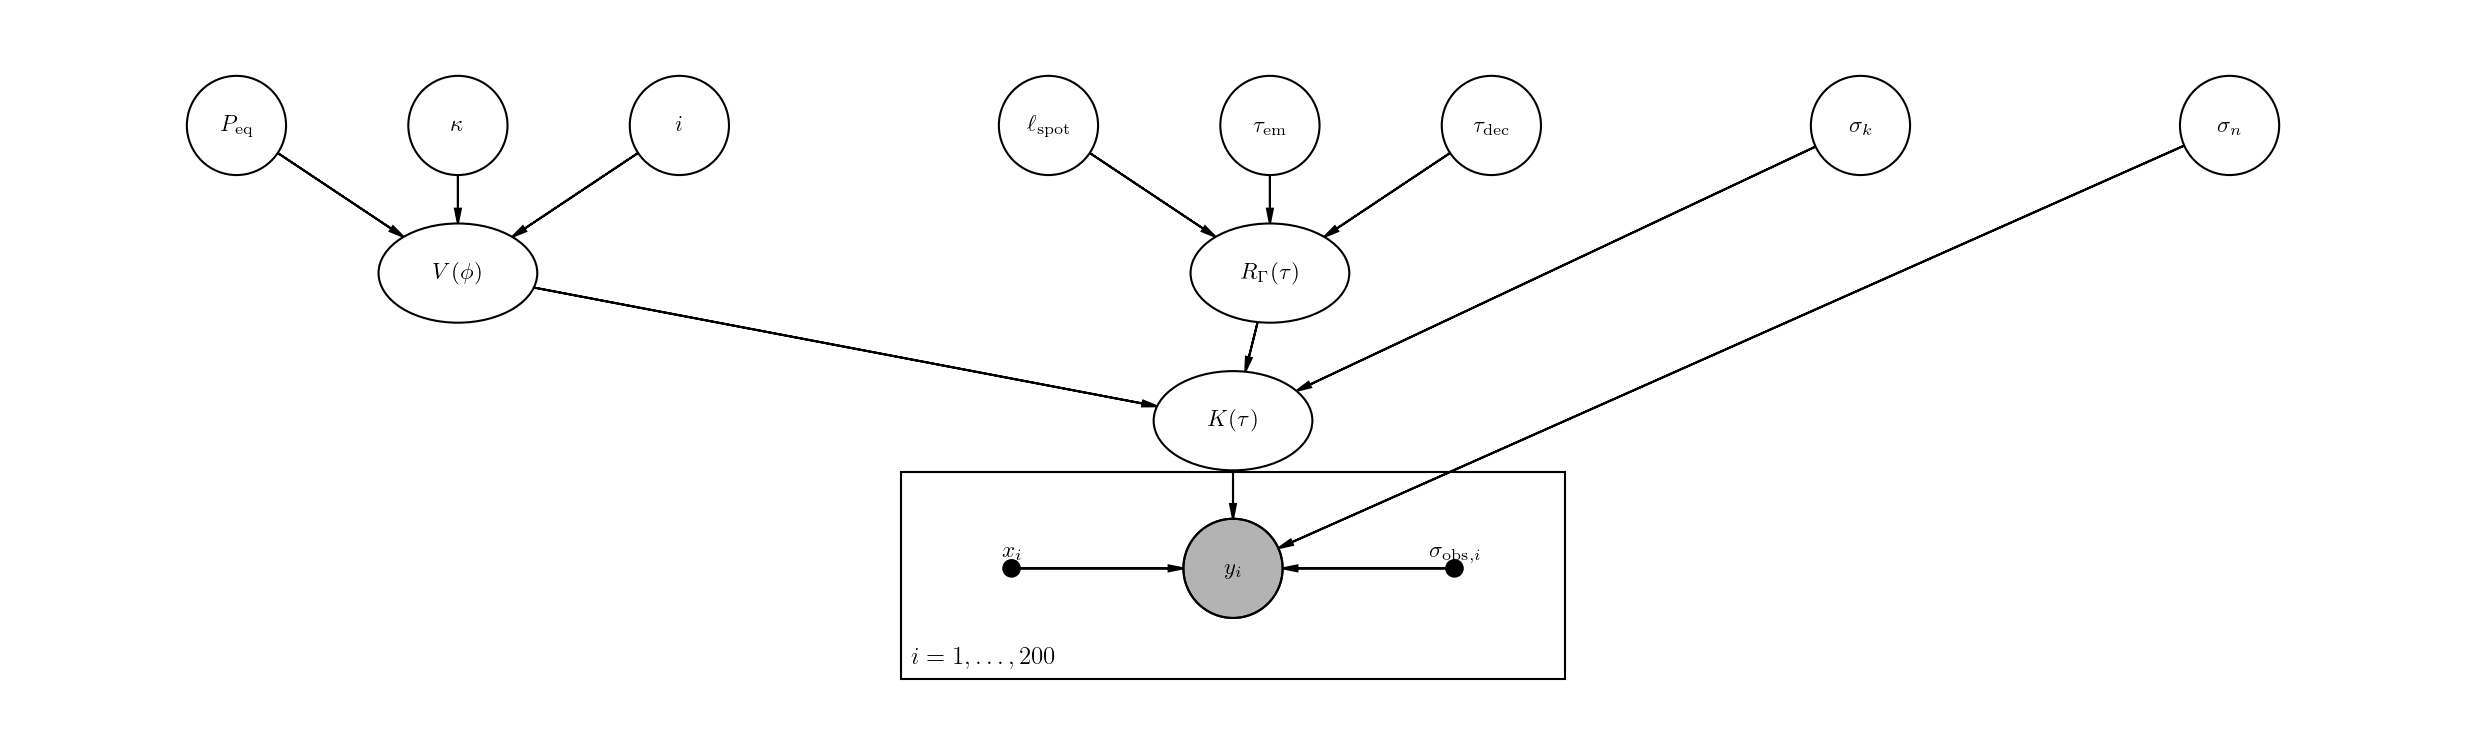

In [4]:
envelope_asym = TrapezoidAsymmetricEnvelope(lspot=5.0, tau_em=1.0, tau_dec=3.0)
visibility = VisibilityFunction(peq=5.0, kappa=0.3, inc=1.2)
model_asym = SpotEvolutionModel(
    envelope=envelope_asym, visibility=visibility, sigma_k=0.01,
)

gp_asym = GPSolver(x, y, yerr, model_asym, fit_sigma_n=True)

print("Free parameters:", gp_asym.param_keys)

fig = gp_asym.plot_pgm()
plt.show()

---
## 4. Multi-band GP

`MultiBandGPSolver` adds the spot temperature $T_{\rm spot}$ as a free
parameter and introduces the wavelength-dependent contrast factor
$c(\lambda) = 1 - B_\lambda(T_{\rm spot}) / B_\lambda(T_{\rm phot})$.

The PGM shows:
- $T_{\rm spot}$ (free, open circle) and $T_{\rm phot}$ (fixed, small dot) feeding into $c(\lambda)$
- $c(\lambda)$ inside a **band plate** ($b = 1, \ldots, B$), since there is one contrast value per photometric band
- The kernel is labeled $K(\tau;\,\lambda)$ to indicate its wavelength dependence

MultiBand banded Cholesky: bandwidth=299, N=300, n_bands=3, sparsity=0.0%
Free parameters: ('peq', 'kappa', 'inc', 'lspot', 'tau_spot', 'sigma_k', 'T_spot', 'sigma_n')
Bands: ['g', 'r', 'i']  (N = 300 total observations)


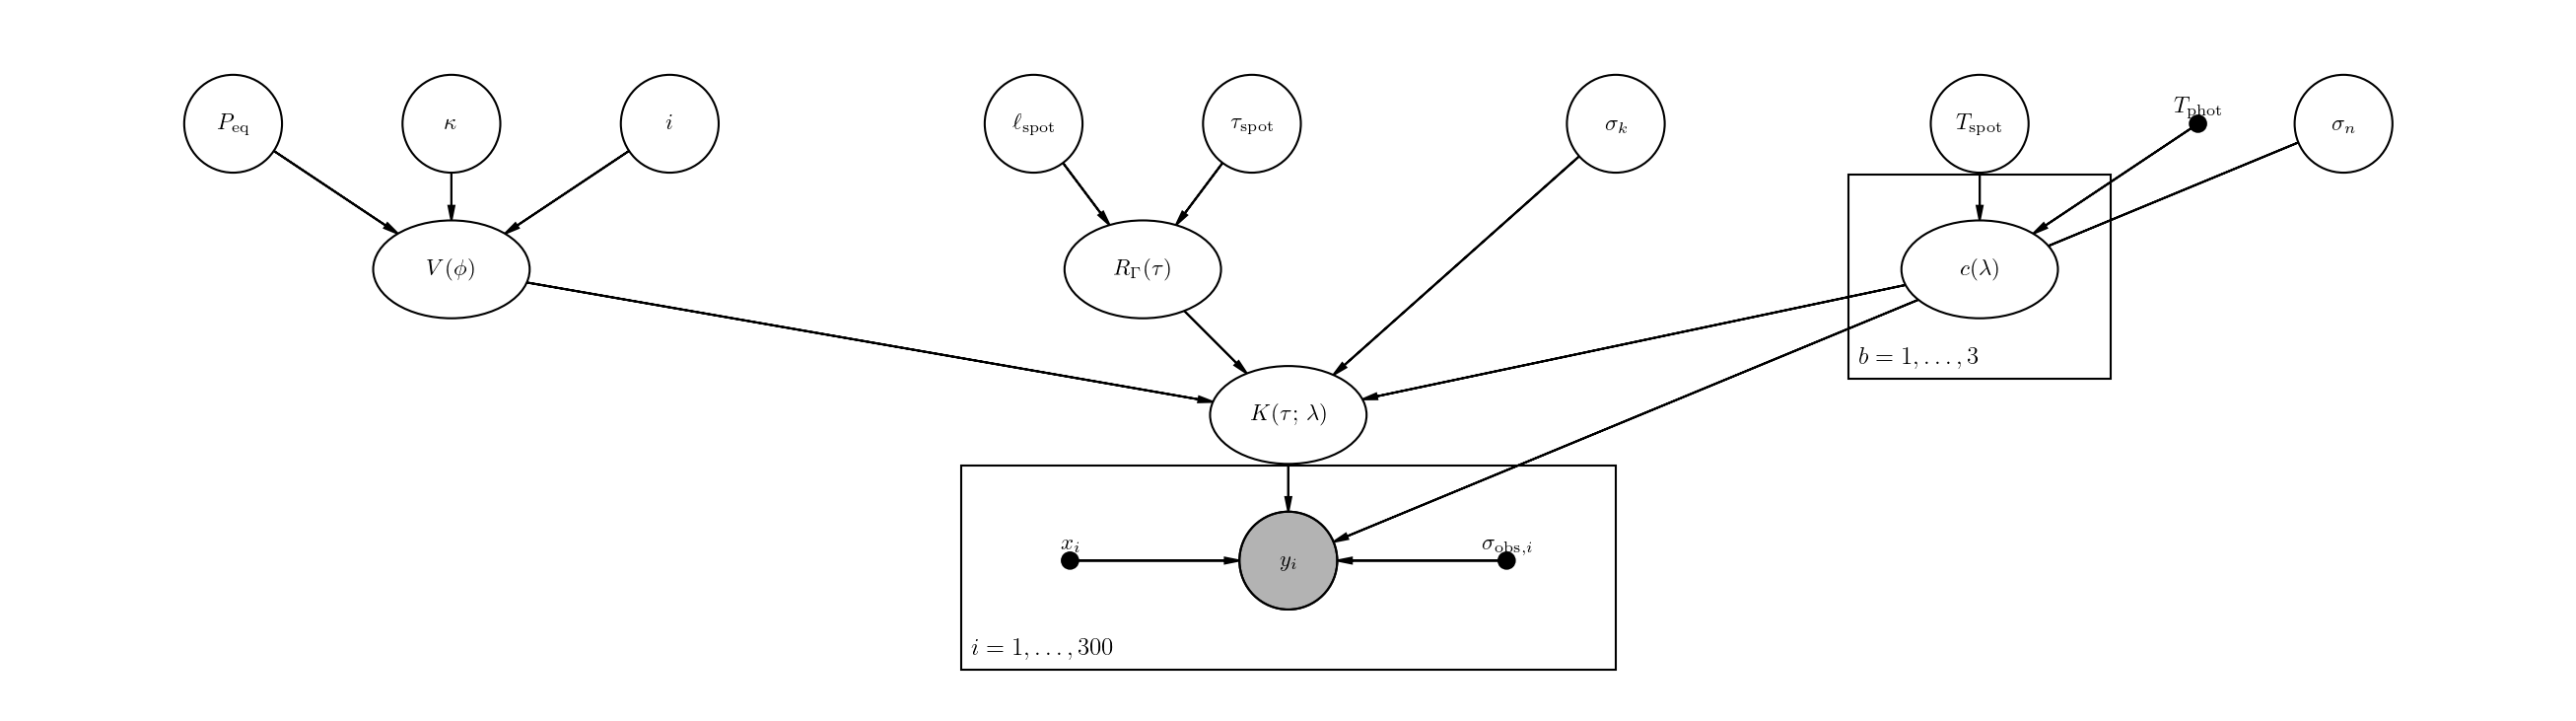

In [5]:
# Build three-band synthetic data
bands = {}
for name, lam in [("g", 4770.0), ("r", 6231.0), ("i", 7625.0)]:
    xb = np.sort(np.random.uniform(0, 30, 100))
    yb = 1.0 + 0.005 * np.sin(2 * np.pi * xb / 5.0) + 0.001 * np.random.randn(100)
    bands[name] = {"x": xb, "y": yb, "yerr": 0.001 * np.ones(100), "wavelength": lam}

data = MultiBandData(bands)

gp_mb = MultiBandGPSolver(
    data,
    hparam,
    T_phot=5800.0,
    T_spot_init=4500.0,
    fit_sigma_n=True,
)

print("Free parameters:", gp_mb.param_keys)
print(f"Bands: {data.band_names}  (N = {data.N} total observations)")

fig = gp_mb.plot_pgm()
plt.show()

---
## 5. Parameter legend

Pass `show_legend=True` to add a key below the diagram that maps each
LaTeX symbol to a descriptive name. This is useful for presentations or
papers where readers may not be familiar with the notation.

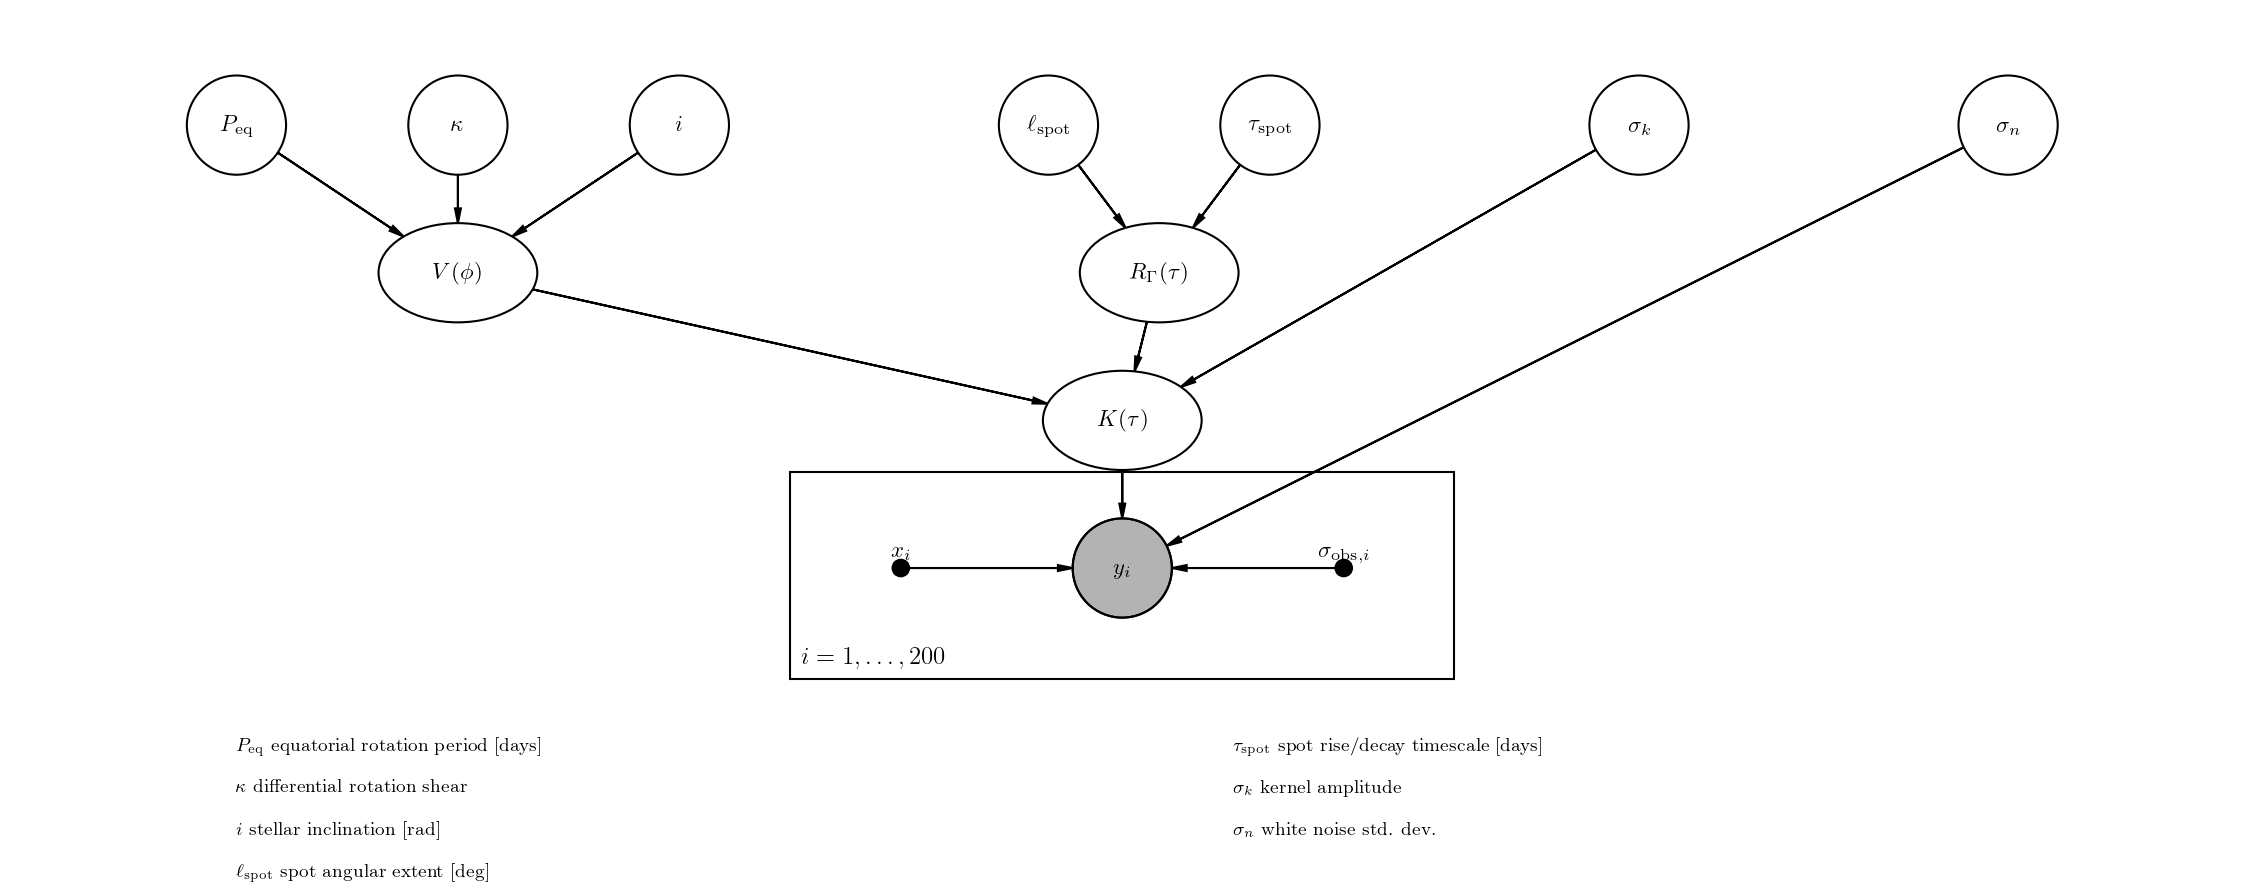

In [6]:
fig = gp_noise.plot_pgm(show_legend=True)
plt.show()

The legend adapts to the model — here is the multi-band case, which
includes $T_{\rm spot}$ and marks $T_{\rm phot}$ as fixed.

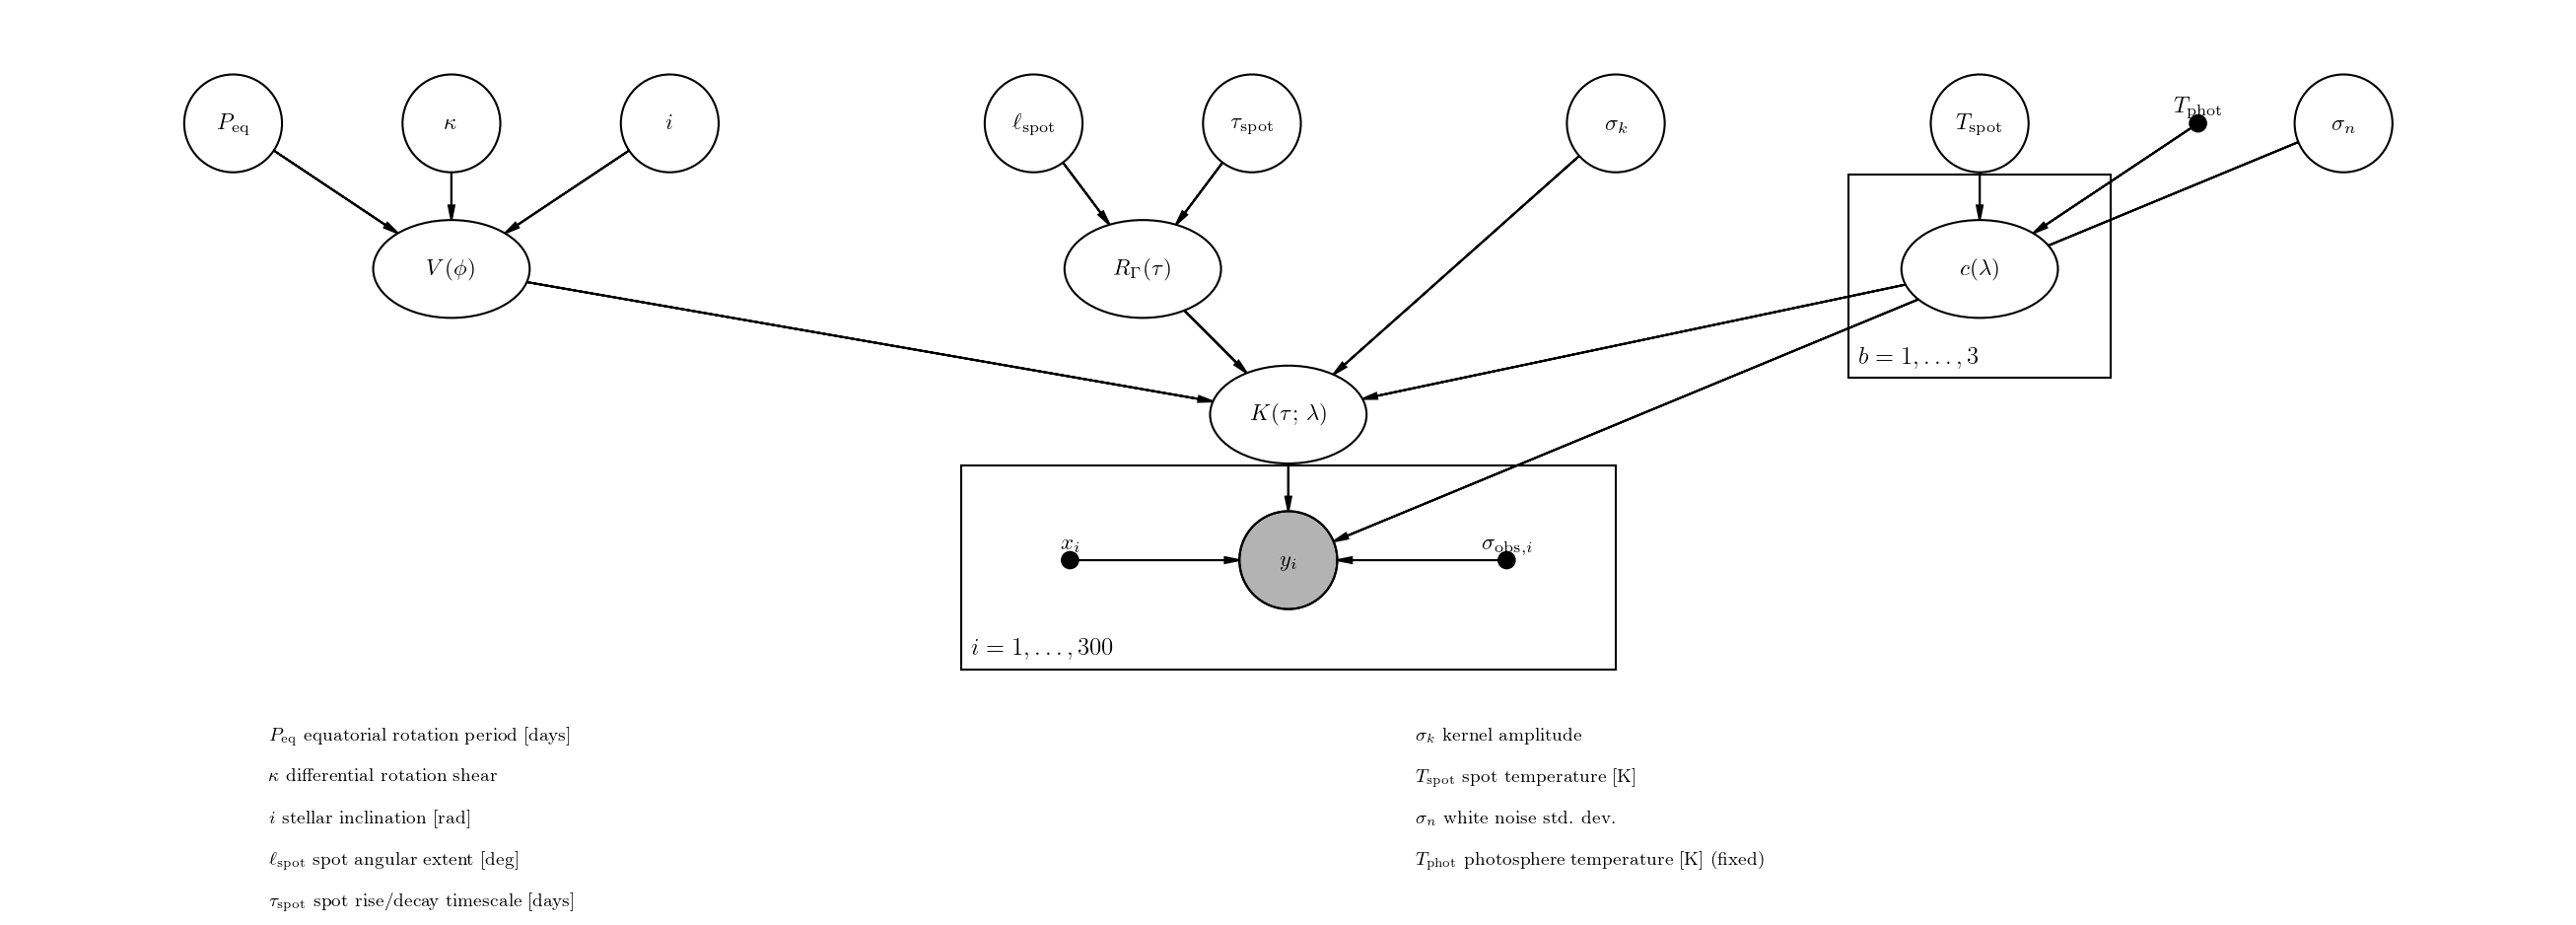

In [7]:
fig = gp_mb.plot_pgm(show_legend=True)
plt.show()

---
## 6. Using `PGModelVis` directly

You can also create a `PGModelVis` object directly to inspect the detected
parameter groups or to customize `dpi`, `node_scale`, and `font_size`.

Rotation params:  ['peq', 'kappa', 'inc']
Envelope params:  ['lspot', 'tau_spot']
Amplitude params: ['sigma_k']
Multiband params: ['T_spot']
Noise params:     ['sigma_n']


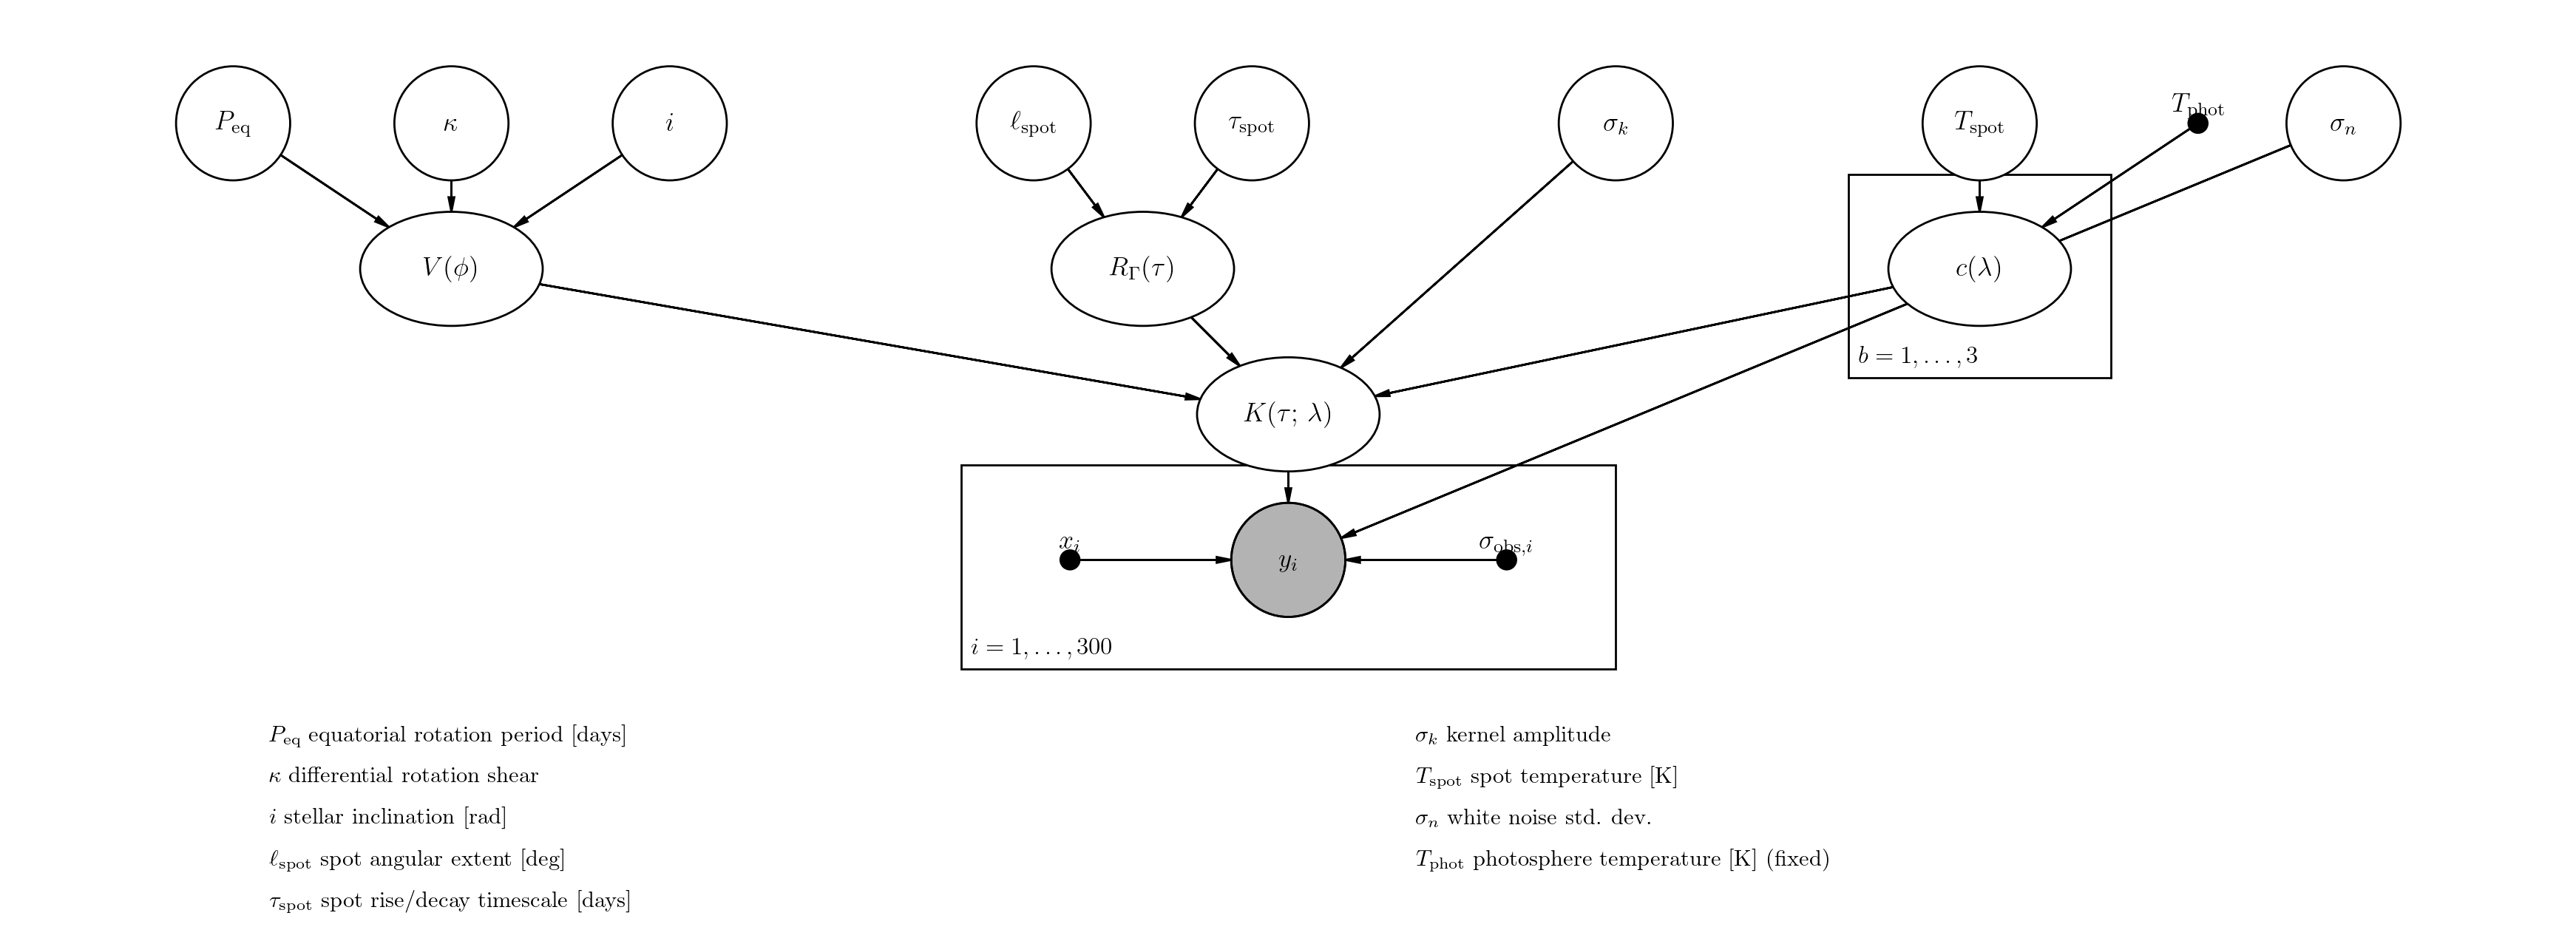

In [8]:
vis = PGModelVis(gp_mb)

print("Rotation params: ", vis.rotation_params)
print("Envelope params: ", vis.envelope_params)
print("Amplitude params:", vis.amplitude_params)
print("Multiband params:", vis.multiband_params)
print("Noise params:    ", vis.noise_params)

fig = vis.render(dpi=200, node_scale=1.4, font_size=13, show_legend=True)
plt.show()